In [1]:
import os
os.chdir("/content/drive/MyDrive/kisco/Data")

In [79]:
import pandas as pd
import numpy as np

csv_data = pd.read_csv("perch.csv")
perch_length = csv_data[["length"]]
perch_weight = csv_data["weight"]

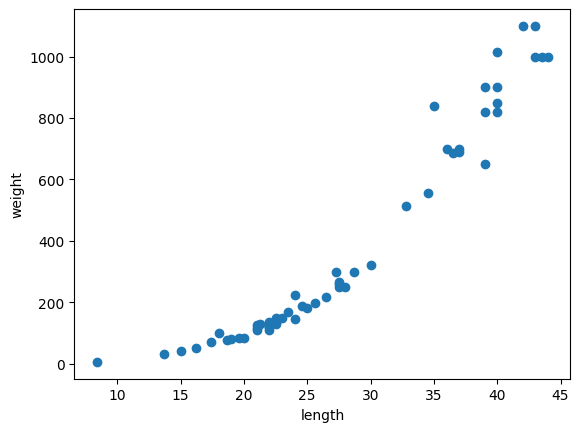

In [4]:
import matplotlib.pyplot as plt
plt.scatter(perch_length, perch_weight)
plt.xlabel("length")
plt.ylabel("weight")
plt.show()

In [117]:
from sklearn.model_selection import train_test_split
train_data, test_data, train_target, test_target = train_test_split(perch_length, perch_weight, random_state=42)
print(train_data.shape, test_data.shape)

(42, 1) (14, 1)


## ***결정 계수 ($ R^2$)***

![결정계수.png](https://blog.kakaocdn.net/dn/bcRJdc/btrfouf07fV/K1nI7k5PUlFi0fVMzgPW60/img.png)

In [99]:
from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor()
model.fit(train_data, train_target)
print(model.score(test_data, test_target))

0.992809406101064


In [100]:
pred_data = pd.read_csv("perch_test.csv")
print(model.predict(pred_data))

[1010. 1010.]


In [101]:
model2 = KNeighborsRegressor(n_neighbors=3)
model2.fit(train_data, train_target)
print(model2.predict([[50]]))

[1033.33333333]


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


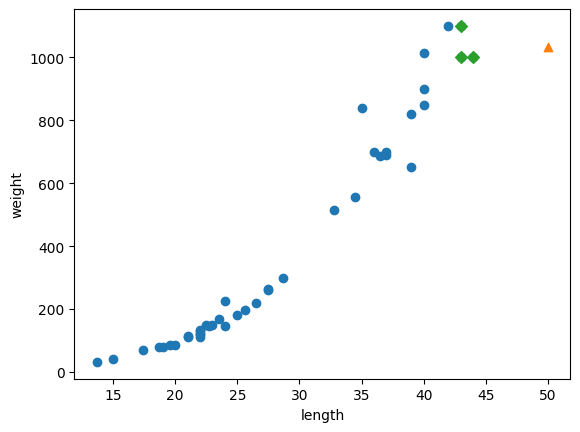

In [102]:
distances, indexes=model2.kneighbors([[50]])

indexes = np.ravel(indexes, order='C')
plt.scatter(train_data, train_target)
plt.scatter(50, 1033, marker="^")
plt.scatter(train_data.iloc[indexes], train_target.iloc[indexes], marker="D")
plt.xlabel("length")
plt.ylabel("weight")
plt.show()

In [103]:
print(np.mean(train_target.iloc[indexes]))

1033.3333333333333


## **선형 회귀**

In [118]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(train_data, train_target)
print("훈련 데이터의 정확도 :", lr_model.score(train_data, train_target))
print("테스트 데이터의 정확도 :", lr_model.score(test_data, test_target))

훈련 데이터의 정확도 : 0.939846333997604
테스트 데이터의 정확도 : 0.8247503123313558


In [119]:
pred_data = lr_model.predict([[50]])
print(pred_data)

[1241.83860323]


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [120]:
pred_data = lr_model.predict([[100]])
print(pred_data)

[3192.69585141]


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [121]:
print(lr_model.coef_, lr_model.intercept_)

[39.01714496] -709.0186449535477


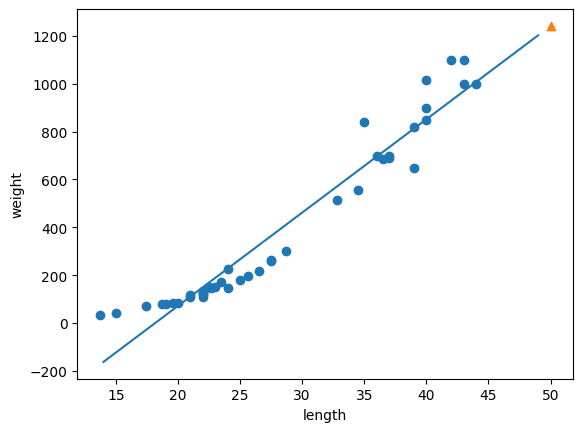

In [122]:
point = np.arange(14, 50)
plt.scatter(train_data, train_target)
plt.plot(point, point * lr_model.coef_ + lr_model.intercept_)
plt.scatter(50,1242, marker="^")
plt.xlabel("length")
plt.ylabel("weight")
plt.show()

In [123]:
train_poly = pd.DataFrame(train_data)
train_poly.insert(0, "length2", train_data ** 2)
print(train_poly.shape)
test_poly = pd.DataFrame(test_data)
test_poly.insert(0, "length2", test_data ** 2)
print(test_poly.shape)
print(test_poly)

(42, 2)
(14, 2)
    length2  length
0     70.56     8.4
5    324.00    18.0
33   756.25    27.5
13   453.69    21.3
19   506.25    22.5
50  1600.00    40.0
36   900.00    30.0
26   605.16    24.6
44  1521.00    39.0
12   441.00    21.0
54  1892.25    43.5
3    262.44    16.2
34   784.00    28.0
30   745.29    27.3


In [128]:
lr_model.fit(train_poly, train_target)
print("훈련 데이터의 정확도 :", lr_model.score(train_poly, train_target))
print("테스트 데이터의 정확도 :", lr_model.score(test_poly, test_target))

훈련 데이터의 정확도 : 0.9706807451768623
테스트 데이터의 정확도 : 0.9775935108325122


In [129]:
pred_data = lr_model.predict([[50**2, 50]])
print(pred_data)

[1573.98423528]


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [130]:
pred_data = lr_model.predict([[100**2, 100]])
print(pred_data)

[8103.57880667]


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [131]:
print(lr_model.coef_, lr_model.intercept_)

[  1.01433211 -21.55792498] 116.05021078278281


In [126]:
train_data, test_data, train_target, test_target = train_test_split(perch_length, perch_weight, random_state=42)
print(train_data.shape, test_data.shape)

(42, 1) (14, 1)


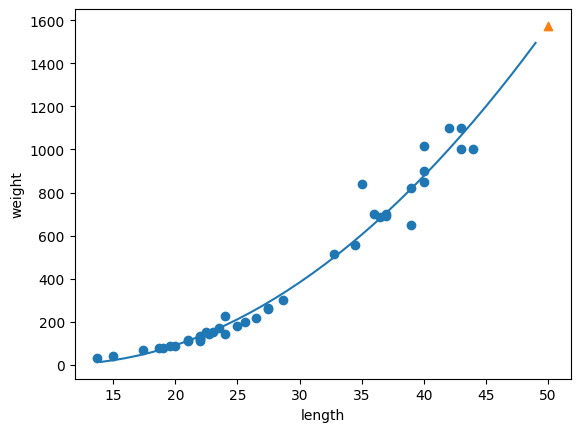

In [132]:
point = np.arange(14, 50)
plt.scatter(train_data, train_target)
plt.plot(point, point**2 * lr_model.coef_[0] + point * lr_model.coef_[1] + lr_model.intercept_)
plt.scatter(50,1574, marker="^")
plt.xlabel("length")
plt.ylabel("weight")
plt.show()